# Housing Price Prediction

## Importing data and Libraries 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
import re
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV


In [2]:
train = pd.read_csv("../Data/house/train.csv")
train_y = train['SalePrice']
train = train.drop(columns=['Id', 'SalePrice'])
test = pd.read_csv("../Data/house/test.csv")
test_id = test['Id']
test = test.drop(columns=['Id'])

## Basic EDA

In [3]:
train.head(5)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


#### Feature Engineering 

In [4]:
# Feature engineering is done before dealing with null values because it makes it easy to add new column
def feature_engineering(df):
    df = df.copy()
    columns = ['Alley', 'BsmtQual', 'PoolQC', 'Fence', 'MiscFeature', 'GarageYrBlt']
    for col in columns:
        prefix = re.match(r'^[A-Z][a-z]*', col).group().lower() 
        # this peace of code is only for making df beautiful making new column this will only pick the Bsmt from BsmtQual and other col 
        df[f'has_{prefix}'] = df[col].notnull().astype(int)
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    return df

train = feature_engineering(train)
test = feature_engineering(test)

#### Checking for null values

Null values will remain the same in both training and testing set as these are not missing values these are predetermined text values

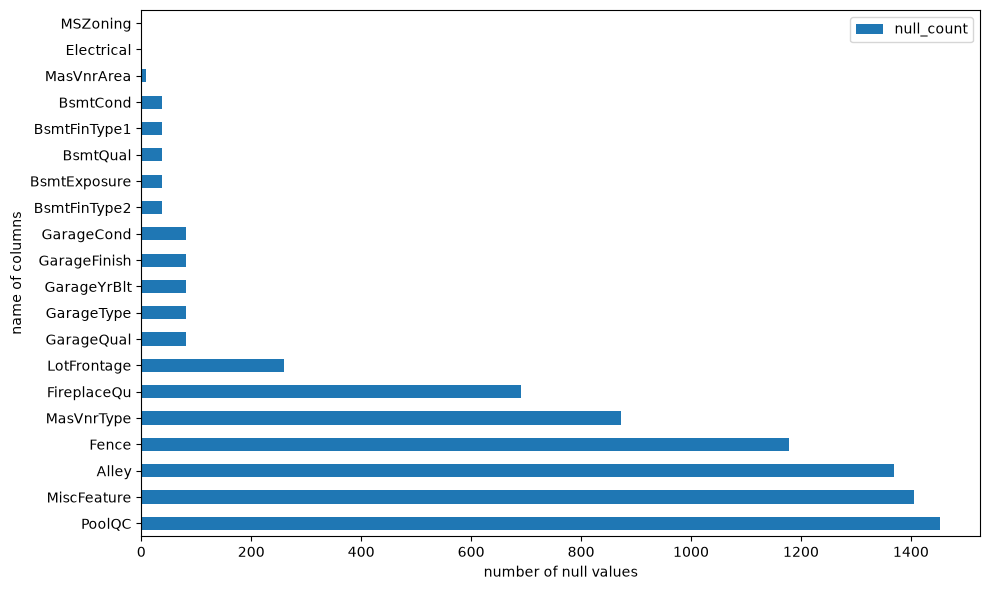

In [5]:
null_data = train.isnull().sum()
null_df = null_data.reset_index()
null_df.columns = ['Column_name', 'null_count']
null_df = null_df.sort_values('null_count', ascending= False)
null_df.head(20).plot(y = "null_count", x = "Column_name", kind= 'barh', figsize=(10, 6))
plt.xlabel('number of null values')
plt.ylabel('name of columns')
plt.tight_layout()
plt.show()

#### Treating Null Values

In [6]:
def null_value(df):
    # Dealing with null values leaving year built behind 
    df = df.copy()
    garage_col = ['GarageYrBlt'] 
    for col in df:
        if col in garage_col: 
            df[col] = df[col].fillna(df['YearBuilt'])
        if df[col].dtype == 'str':
            df[col] = df[col].fillna('None')
        elif df[col].dtype in ('int', 'float'):
            df[col] = df[col].fillna(0)
    return df    
    
    # Always use 'in' rather that '==' as this will not have precedence over 'in' if you want to try replace 'in' from exclude_col line with '=='
    # Alternate way to deal with null values
    # ---- Code ----
    # cat_cols = df.select_dtypes(include = 'str').columns
    # df[cat_cols] = df[cat_cols].fillna('None')
    # int_cols = df.select_dtypes(include = 'int', 'float').columns
    # df[int_cols] = df[int_cols].fillna('0')
    # return df
    # ---- Code ----
    # this will not leave behind the column we want as we are leaving year built behind as we have to deal with it separately

train = null_value(train)
test = null_value(test)

#### Encoding Values


##### Ordinal encoder

In [7]:
# First treating the Quality Parameters
group = ['ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual', 'BsmtQual', 'BsmtCond', 'FireplaceQu', 'GarageQual', 'GarageCond']
group_t = ['PoolQC']
group_fence = ['Fence']
group_garage = ['GarageFinish']
group_bsmt = ['BsmtExposure']
group_fin = ['BsmtFinType1', 'BsmtFinType2']

cat_catg = ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
cat_catg_t = ['None', 'Fa', 'TA', 'Gd', 'Ex']
cat_catg_fence = ['None', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv']
cat_catg_garage = ['None', 'Unf', 'RFn', 'Fin']
cat_catg_bsmt = ['None', 'No', 'Mn', 'Av', 'Gd']
cat_catg_fin = ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']

for col in group:
    enc = OrdinalEncoder(categories= [cat_catg])
    train[col] = enc.fit_transform(train[[col]])
    test[col] = enc.transform(test[[col]])
   
for col in group_t:
    enc = OrdinalEncoder(categories= [cat_catg_t])
    train[col] = enc.fit_transform(train[[col]])
    test[col] = enc.transform(test[[col]])

for col in group_fence:
    enc = OrdinalEncoder(categories= [cat_catg_fence])
    train[col] = enc.fit_transform(train[[col]])
    test[col] = enc.transform(test[[col]])

for col in group_garage:
    enc = OrdinalEncoder(categories= [cat_catg_garage])
    train[col] = enc.fit_transform(train[[col]])
    test[col] = enc.transform(test[[col]])

for col in group_bsmt:
    enc = OrdinalEncoder(categories= [cat_catg_bsmt])
    train[col] = enc.fit_transform(train[[col]])
    test[col] = enc.transform(test[[col]])

for col in group_fin:
    enc = OrdinalEncoder(categories= [cat_catg_fin])
    train[col] = enc.fit_transform(train[[col]])
    test[col] = enc.transform(test[[col]])

##### OneHot Encoding

In [8]:
def get_str_col(df):
    return df.select_dtypes(include = 'str').columns.tolist()

train_str_col = get_str_col(train)
test_str_col = get_str_col(test)

ohe = OneHotEncoder(handle_unknown= 'ignore', sparse_output = False)
train_encoded = ohe.fit_transform(train[train_str_col])
test_encoded = ohe.transform(test[test_str_col])

train_encoded_df = pd.DataFrame(train_encoded, columns=ohe.get_feature_names_out(train_str_col), index= train.index)
test_encoded_df = pd.DataFrame(test_encoded, columns=ohe.get_feature_names_out(test_str_col), index= test.index)

train = train.drop(columns= train_str_col).join(train_encoded_df)
test = test.drop(columns= test_str_col).join(test_encoded_df)

#### Feature Scaling

In [9]:
Sc = StandardScaler()
def scaling_col(df):
    return df.loc[:, :'HouseAge'].columns.tolist()

continuous_train = scaling_col(train)
continuous_test = scaling_col(test)

train[continuous_train] = Sc.fit_transform(train[continuous_train])
test[continuous_test] = Sc.transform(test[continuous_test])

In [10]:
train.shape[1]

248

#### Training model 

In [11]:
param_grid_xgb = {
    'n_estimators': [300, 500, 800],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}
xgb = XGBRegressor(random_state=42)
grid_search_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
grid_search_xgb.fit(train, train_y)
best_xgb = grid_search_xgb.best_estimator_

# Ridge tuning
param_grid_ridge = {'alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]}
ridge = Ridge()
grid_search_ridge = GridSearchCV(ridge, param_grid_ridge, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search_ridge.fit(train, train_y)
best_ridge = grid_search_ridge.best_estimator_

# Random Forest tuning
param_grid_rf = {
    'n_estimators': [200, 500, 800],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10]
}
rf = RandomForestRegressor(random_state=42)
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search_rf.fit(train, train_y)
best_rf = grid_search_rf.best_estimator_

# predictions using the tuned/fitted models — not the unfit originals
ridge_test = best_ridge.predict(test)
rf_test = best_rf.predict(test)
xgb_test = best_xgb.predict(test)

predictions = 0.5 * xgb_test + 0.3 * rf_test + 0.2 * ridge_test

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


In [12]:
output = pd.DataFrame({'Id': test_id, 'SalePrice': predictions})
output.to_csv('submission.csv', index=False)